<a href="https://colab.research.google.com/github/rylan-berry/DeepLearningIndependentStudy/blob/main/RNNDeeplearningProblemSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Complete Problem Set: Recurrent Neural Networks

This problem set is designed to test your understanding of Recurrent Neural Networks (RNNs), covering theoretical aspects, architectural components, training challenges, and practical applications, along with hands-on coding exercises.

---



### Theoretical Written Questions

1.  **Theoretical Foundations:** Explain the fundamental principles of Recurrent Neural Networks (RNNs) in terms of their input structure and how they process sequential data. Discuss how RNNs maintain a 'memory' of past inputs through their hidden state and the concept of 'unrolling' an RNN over time.

- *RNNs function like a chain from run moment to run moment. They take some memory from the previous runtime and use it in the current run. This can backpropagate to the previous runs as well. The concept of 'unrolling' pretty much visualizes the flow of this hidden memory.*

2.  **Architectural Components:** Describe the typical architectural components of a vanilla Recurrent Neural Network, including the input layer, hidden layer with recurrent connections, output layer, and activation functions. Explain the role of the recurrent weight matrix ($W_{hh}$) and input weight matrix ($W_{xh}$). How does the hidden state capture information from the sequence?

- *The input layer takes in and applies weights to the input, activation functions apply some non-lineariy where-ever they are used, output layer is the output (simple enough). The hidden layers with recurrent connections are where the memory is updated, and then where the memory is read for use in the current model. Usually, this memory will have it's own weights for when it is used in the model.*

3.  **Training Challenges:** What are the significant training challenges associated with vanilla Recurrent Neural Networks, particularly concerning gradient propagation? Elaborate on the vanishing and exploding gradient problems. Discuss Backpropagation Through Time (BPTT) and common strategies proposed to mitigate these gradient issues (e.g., gradient clipping, architectural changes like LSTMs/GRUs).

- *The main challenges are exploding and vanishing graident. Either usually occur because of the repeated operations against the memory, which can either make gradients really small and underflow (vanishing) or get really large and overflow (eploding). Because of the setup of these models, we're able to backprop through time via the memory. Common strategies include limiting the memory depth, or more recently are gated options Long Short-Term Memory (LSTM) or Gated Recurrent Unit (GRU). LSTMs are set up to have the memory layer add and lose information in acordance to gates, I may need to research it more but that's the gist. GRUs are similar but instead of multiple gates from LSTMs it uses one gate to control it all!*

4.  **Practical Applications:** Enumerate and describe at least three distinct practical applications where Recurrent Neural Networks have shown significant success. For each application, explain why the sequential processing capability of RNNs is particularly well-suited for the task, providing concrete examples.

- *A big use is audio processing, instead of trying to feed in a constant size of audio, you can send the current segment and rely on past information about what came before. Similarly is natural language processing, which would be similar to this audio setup but instead for words. Another that would make sense is video processing, especially if you mix in a CNN I could see it being very powerful.*

5.  **Comparison and Limitations:** How do vanilla Recurrent Neural Networks compare to more advanced sequence models like LSTMs, GRUs, and briefly, Transformers (in the context of sequential data)? Discuss scenarios where simpler RNNs might be suitable, as well as their inherent limitations (e.g., difficulty with long-term dependencies) and how LSTMs/GRUs address these.

- *Vanilla RNNs typically have 'shorter' memory due to it's linear nature. LSTMs and GRUs attempt to allow longer memory but selectivly adjusting the memory instead of outright using a hidden layer as the next memory. However, Transformers throw all of this out of the window since they rely on large context windows and inferencing (using the model output in future models' input)*

6.  **Variations and Extensions:** Briefly discuss at least two variations or extensions of the basic Recurrent Neural Network model (e.g., Long Short-Term Memory (LSTM) networks, Gated Recurrent Units (GRUs), Bidirectional RNNs). Explain how these variations address specific limitations of the basic model or enhance its capabilities, focusing on their gating mechanisms (for LSTMs/GRUs).

- *Bidirectionl RNNs are weird since not only do they take past memory, they take **future** memory, using future memory feels weird but my guess is that it does an intial pass then goes back runs again (but idk). Echo State Networks say to set up the memory weights before the model, having them good enough and making the model only worry about it's output weights.*

7.  **Data Representation:** How is sequential data typically represented and prepared for input into a Recurrent Neural Network? Discuss concepts such as one-hot encoding, word embeddings, sequence padding, and truncation, and their importance in training RNNs.

- *One-hot encoding is used when you have multiple input types (typically categories), and instead of having a single input for all of them, you have a input for **each** category, and you set it to be 1 or 0 if it is that category. This removes a step for the model of having to parse that an input is a category and instead its a yes it's this things or no it's not this thing. Most Large Language Models(LLMS) do this to words(tokens). One-hot is just useful for NNs in general. Word embeddings take the word and make it a point in a highdimensional space to give it meaning. In LLMs, this is calculated by the model automatically. Sequence padding is what it sounds like, adding zeros to fit an input size requirement (also used in LLMs since most text is smaller than it's context window). Truncating is when you break up some sequence into multiple sequences where the sequence has just one item, the second has two, and so on until you get the orginal sequence back. I've seen this mostly in LLMs since it relies on large context windows and so that when training for the next work it doesn't try to cheat with future content. These all can be used in RNNs, but RNNs are meant to have flexible sizes, I thin word embedding and one-hot would be more likely to be used then sequence padding and truncation.*

---
### Practical Coding Questions

In [1]:
import numpy as np

---
#### Question 1: Implementing a Simple RNN Cell Forward Pass

**Objective:** Implement a fundamental Recurrent Neural Network (RNN) cell that takes a current input and a previous hidden state to compute a new hidden state and an optional output.

**Task:**

Write a Python function `rnn_cell_forward(x_t, h_prev, W_xh, W_hh, b_h, W_hy, b_y)` that performs the following for a single time step `t`:

1.  Takes the current input vector `x_t` (NumPy array) and the previous hidden state `h_prev` (NumPy array) as input.
2.  Applies a linear transformation to `x_t` using `W_xh` and a linear transformation to `h_prev` using `W_hh`.
3.  Combines these transformed vectors, adds a bias `b_h`, and applies an activation function (e.g., `tanh`) to compute the new hidden state `h_t`.
4.  Optionally, applies another linear transformation using `W_hy` and `b_y` to `h_t` to compute an output `y_t` (you can use a `softmax` activation for classification if desired, or no activation for regression, but for simplicity, a linear output is fine).
5.  Returns the new hidden state `h_t` and the output `y_t`.

**Input Details:**

*   `x_t`: A 1-dimensional NumPy array representing the input at time `t`.
*   `h_prev`: A 1-dimensional NumPy array representing the hidden state at time `t-1`.
*   `W_xh`: Weight matrix for input to hidden state transformation.
*   `W_hh`: Weight matrix for hidden state to hidden state transformation.
*   `b_h`: Bias vector for the hidden state.
*   `W_hy`: Weight matrix for hidden state to output transformation.
*   `b_y`: Bias vector for the output.

**Expected Output:**

*   `h_t`: A NumPy array representing the new hidden state at time `t`.
*   `y_t`: A NumPy array representing the output at time `t`.

In [2]:
def rnn_cell_forward(x_t, h_prev, W_xh, W_hh, b_h, W_hy, b_y):
  h_t = np.tanh(W_xh @ x_t + W_hh @ h_prev + b_h)
  y_t = W_hy @ h_t + b_y
  return h_t, y_t


# Assuming some dimensions
input_dim = 10
hidden_dim = 20
output_dim = 5
batches = 3

# Example weights and biases (randomly initialized)
W_xh_ex = np.random.rand(hidden_dim, input_dim)
W_hh_ex = np.random.rand(hidden_dim, hidden_dim)
b_h_ex = np.random.rand(hidden_dim,1)
W_hy_ex = np.random.rand(output_dim, hidden_dim)
b_y_ex = np.random.rand(output_dim,1)

# Example usage:
x_t_ex = np.random.rand(input_dim, batches) # Current input
h_prev_ex = np.random.rand(hidden_dim, batches) # Previous hidden state

h_t_ex, y_t_ex = rnn_cell_forward(x_t_ex, h_prev_ex, W_xh_ex, W_hh_ex, b_h_ex, W_hy_ex, b_y_ex)

print('New Hidden State:', h_t_ex.shape)
print('Output:', y_t_ex.shape)

New Hidden State: (20, 3)
Output: (5, 3)


---
#### Question 2: Building a Simplified RNN Sequence Forward Pass

**Objective:** Implement the forward pass of a simplified Recurrent Neural Network that processes an entire sequence of inputs, utilizing the `rnn_cell_forward` function from Question 1.

**Task:**

Write a Python function `rnn_sequence_forward(input_sequence, initial_h, W_xh, W_hh, b_h, W_hy, b_y)` that processes a sequence of input vectors:

1.  Takes a list of NumPy arrays `input_sequence` (each array is an input `x_t` for a time step) and an `initial_h` (the starting hidden state `h_0`).
2.  Uses the `rnn_cell_forward` function (from Question 1) to iterate through the `input_sequence`.
3.  At each time step `t`, it computes `h_t` and `y_t` using `x_t` and `h_{t-1}`.
4.  Collects all hidden states `h_t` and outputs `y_t` for each time step in lists.
5.  Returns the list of all hidden states and the list of all outputs.

**Input Details:**

*   `input_sequence`: A list of 1-dimensional NumPy arrays, where each array is an input vector `x_t`.
*   `initial_h`: A 1-dimensional NumPy array representing the initial hidden state `h_0`.
*   `W_xh`, `W_hh`, `b_h`, `W_hy`, `b_y`: The weight matrices and bias vectors required by `rnn_cell_forward`.

**Expected Output:**

*   `all_hidden_states`: A list of NumPy arrays, where each element is `h_t` for a given time step.
*   `all_outputs`: A list of NumPy arrays, where each element is `y_t` for a given time step.

In [3]:
def rnn_sequence_forward(input_sequence, initial_h, W_xh, W_hh, b_h, W_hy, b_y):
  h = [initial_h]
  y = []
  h_t = initial_h
  for x_t in input_sequence:
    h_t, y_t = rnn_cell_forward(x_t, h_t, W_xh, W_hh, b_h, W_hy, b_y)
    h.append(h_t); y.append(y_t)
  return h, y



# Example usage:
sequence_length = 7
input_sequence_ex = np.random.rand(sequence_length,input_dim, batches)
initial_h_ex = np.zeros((hidden_dim,batches)) # Or np.random.rand(hidden_dim)

all_h_ex, all_y_ex = rnn_sequence_forward(input_sequence_ex, initial_h_ex, W_xh_ex, W_hh_ex, b_h_ex, W_hy_ex, b_y_ex)



print('New Hidden State:', np.array(all_h_ex).shape)
print('Output:', np.array(all_y_ex).shape)

New Hidden State: (8, 20, 3)
Output: (7, 5, 3)


---
####AK Q1

**Example (Illustrative - you will define Ws and bs):**

```python
import numpy as np

def rnn_cell_forward(x_t, h_prev, W_xh, W_hh, b_h, W_hy, b_y):
    # Calculate new hidden state
    h_t = np.tanh(np.dot(W_xh, x_t) + np.dot(W_hh, h_prev) + b_h)

    # Calculate output
    y_t = np.dot(W_hy, h_t) + b_y # Linear output for simplicity
    return h_t, y_t

# Assuming some dimensions
input_dim = 10
hidden_dim = 20
output_dim = 5

# Example weights and biases (randomly initialized)
W_xh_ex = np.random.rand(hidden_dim, input_dim)
W_hh_ex = np.random.rand(hidden_dim, hidden_dim)
b_h_ex = np.random.rand(hidden_dim)
W_hy_ex = np.random.rand(output_dim, hidden_dim)
b_y_ex = np.random.rand(output_dim)

# Example usage:
x_t_ex = np.random.rand(input_dim) # Current input
h_prev_ex = np.random.rand(hidden_dim) # Previous hidden state

h_t_ex, y_t_ex = rnn_cell_forward(x_t_ex, h_prev_ex, W_xh_ex, W_hh_ex, b_h_ex, W_hy_ex, b_y_ex)

# print('New Hidden State:', h_t_ex.shape)
# print('Output:', y_t_ex.shape)
```

---
####AK Q2

**Example Usage (using the variables defined in Question 1):**

```python
# Assume input_dim, hidden_dim, output_dim, and Ws/bs are defined as in Question 1

def rnn_sequence_forward(input_sequence, initial_h, W_xh, W_hh, b_h, W_hy, b_y):
    all_hidden_states = []
    all_outputs = []
    h_current = initial_h

    for x_t in input_sequence:
        h_current, y_t = rnn_cell_forward(x_t, h_current, W_xh, W_hh, b_h, W_hy, b_y)
        all_hidden_states.append(h_current)
        all_outputs.append(y_t)

    return all_hidden_states, all_outputs

# Example usage:
sequence_length = 7
input_sequence_ex = [np.random.rand(input_dim) for _ in range(sequence_length)]
initial_h_ex = np.zeros(hidden_dim) # Or np.random.rand(hidden_dim)

all_h_ex, all_y_ex = rnn_sequence_forward(input_sequence_ex, initial_h_ex, W_xh_ex, W_hh_ex, b_h_ex, W_hy_ex, b_y_ex)

# print('Number of hidden states:', len(all_h_ex))
# print('Shape of first hidden state:', all_h_ex[0].shape)
# print('Number of outputs:', len(all_y_ex))
# print('Shape of first output:', all_y_ex[0].shape)
```

---

###Implement RNN into library

In [4]:
!python3 -m pip install --upgrade rb-deeplearning-lib

  Attempting uninstall: rb-deeplearning-lib
    Found existing installation: rb-deeplearning-lib 0.3.8
    Uninstalling rb-deeplearning-lib-0.3.8:
      Successfully uninstalled rb-deeplearning-lib-0.3.8


In [5]:
from rb_deeplearning_lib import Values, Model

In [6]:
class FullRNNLayer:
  def __init__(self, input_dim, hidden_dim, output_dim, rangeW=(0,1),rangeB=(0,1), activ="tanh", transpInput=False):
    self.hidd_dim = hidden_dim
    self.out_dim = output_dim

    self.W_xh = Values((rangeW[0]-rangeW[1])*np.random.rand(input_dim, hidden_dim)+rangeW[1])
    self.W_hh = Values((rangeW[0]-rangeW[1])*np.random.rand(hidden_dim, hidden_dim)+rangeW[1])
    self.b_h = Values((rangeW[0]-rangeW[1])*np.random.rand(1,hidden_dim)+rangeW[1])
    self.W_hy = Values((rangeW[0]-rangeW[1])*np.random.rand(hidden_dim,output_dim)+rangeW[1])
    self.b_y = Values((rangeW[0]-rangeW[1])*np.random.rand(1,output_dim)+rangeW[1])
    self.activ = activ
    self.transpInput = transpInput

  def _rnn_cell_forward(self, x_t, h_prev):
    # Corrected 'self.active' to 'self.activ' and added function call '()'
    # If self.activation is not a valid method name, it will raise an AttributeError.

    #x_t ~ (B, D); h_t ~ (B,H); y_t ~ (B,O);
    h_t = getattr((x_t @ self.W_xh + h_prev @self.W_hh + self.b_h), self.activ)()
    y_t = h_t @ self.W_hy + self.b_y
    return h_t, y_t


  def __call__(self,x): #Assumed first dimension is time dimension, assumed final dimension is batch dimension
    x_n = x
    if self.transpInput: #assuming (B,T,D) and converting to (T,B,D)
      axis = list(range(len(x.shape))) #create list from 0 to total input dims
      axis[0]=1;axis[1]=0

      x_n = x.transpose(axis)
    x_siz = x_n.vals.shape # Use .vals to get numpy shape for Values object
    # Initial hidden state needs to match batch dimension of inputs
    h_t = Values(np.zeros((x_siz[1],self.hidd_dim, ))) # x_siz[1] will be batch_size if x_n is (Time, Batch, Data)


    h = []
    all_y_ts = Values(np.zeros((x_siz[0],x_siz[1], self.out_dim))) # Should collect as a Values variable and not a list, should output as (T, B, O)

    for i, x_t in enumerate(x_n):
        h_t, y_t = self._rnn_cell_forward(x_t, h_t)
        h.append(h_t)
        all_y_ts[i] = y_t

    fin_out = all_y_ts
    if self.transpInput:
      axis = list(range(len(x.shape)))
      axis[0]=1;axis[1]=0

      fin_out = all_y_ts.transpose(axis)

    return fin_out

  def params(self):
    return self.W_xh, self.W_hh, self.b_h, self.W_hy, self.b_y

#I want to also make a partial RNN layer(s) so things can be changed around it -- may not do this because of time.
#Change the output to be a Values that we can set the items of. then make the output fill that in


In [7]:
import rb_deeplearning_lib as rb
import numpy as np

# Define dimensions for the sample data
batches = 32
sequence_length = 10
input_features = 2  # Matches inL of the first Dense layer
output_features = 2 # Matches output_dim of FullRNNLayer

# Generate sample input data (batches, time, data)
x = Values(np.random.rand(batches, sequence_length, input_features))
# Generate sample target data (batches, time, output_features)
y = Values(np.random.rand(batches, sequence_length, output_features))

m = rb.Model([rb.Dense(layNum=2,inL=2,midL=8,outL=8, activ="relu",f_activ="relu"), FullRNNLayer(8,8,2, transpInput=True)],loss_fn=rb.mse_loss)
m.train(20, x,y,x,y, l_rate=0.1,val_run=4)
#m(x)

epoch: 0 	 loss: 15.986621197067937
epoch: 4 	 loss: 0.08456699343846072
epoch: 8 	 loss: 0.08423816951716807
epoch: 12 	 loss: 0.08395069523314971
epoch: 16 	 loss: 0.08369615532144883
epoch: 20 	 loss: 0.08347067683584256


####Version where FullRNNLayer comes from the library.

In [8]:
from rb_deeplearning_lib import Model, FullRNNLayer, mse_loss
import numpy as np

# Define dimensions for the sample data
batches = 32
sequence_length = 10
input_features = 2  # Matches inL of the first Dense layer
output_features = 2 # Matches output_dim of FullRNNLayer

# Generate sample input data (batches, time, data)
x = np.random.rand(batches, sequence_length, input_features)
# Generate sample target data (batches, time, output_features)
y = np.random.rand(batches, sequence_length, output_features)

m = rb.Model([rb.Dense(layNum=2,inL=2,midL=8,outL=8, activ="relu",f_activ="relu"), FullRNNLayer(8,8,2, transpInput=True)],loss_fn=mse_loss)
m.train(20, x,y,x,y, l_rate=0.1,val_run=4)

epoch: 0 	 loss: 16.833601168967633
epoch: 4 	 loss: 0.08537563493359904
epoch: 8 	 loss: 0.08514536920035624
epoch: 12 	 loss: 0.08492845131074755
epoch: 16 	 loss: 0.0847225837523298
epoch: 20 	 loss: 0.08452702272690668


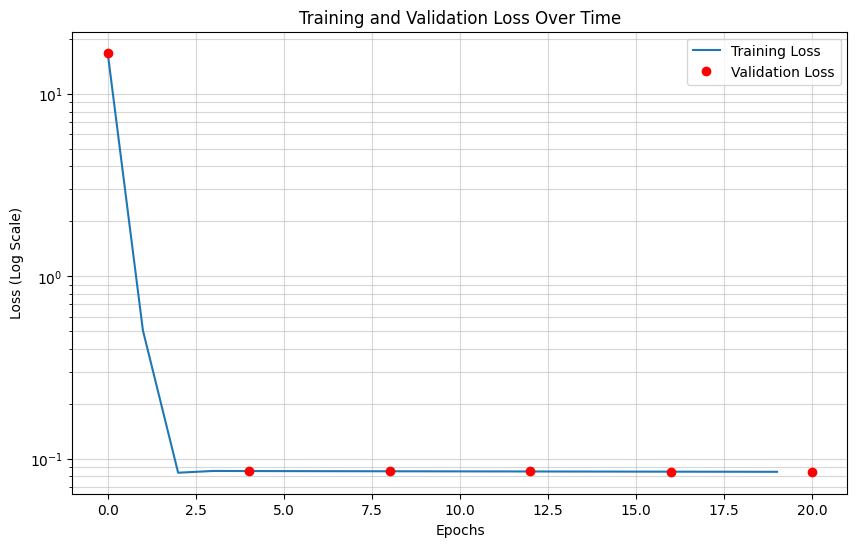

In [11]:
import matplotlib.pyplot as plt

# Extracting epochs and loss values
train_epochs, train_losses = zip(*m.train_loss)
val_epochs, val_losses = zip(*m.val_loss)

plt.figure(figsize=(10, 6))
plt.plot(train_epochs, train_losses, label='Training Loss')
plt.plot(val_epochs, val_losses, 'ro', label='Validation Loss')

plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss (Log Scale)')
plt.title('Training and Validation Loss Over Time')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()